In [12]:
# ============================================================
# 5.2.3 Evaluation of Gradient Boosting (Base vs Tuned) — FULL
# ============================================================
# This notebook section:
# 1) Loads cleaned dataset
# 2) Encodes airfoilName
# 3) Selects features (CST coeffs + flow vars + encoded airfoil)
# 4) Cleans + scales features
# 5) Evaluates BASE Gradient Boosting for Cl and Cd (3-fold CV)
# 6) Evaluates TUNED Gradient Boosting for Cl and Cd (3-fold CV)
# 7) Produces report-ready tables:
#    - Base (Cl vs Cd)
#    - Tuned (Cl vs Cd)
#    - Base vs Tuned comparison (like senior sample)
# 8) (Optional) Learning curve plot for Cd
# ============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate, learning_curve

import matplotlib.pyplot as plt


In [14]:
# -----------------------------
# CELL 1: Load dataset
# -----------------------------
CLEAN_CSV_PATH = "AirfoilDatset_cleaned_1.csv"  # ensure this file is beside your ipynb
df = pd.read_csv(CLEAN_CSV_PATH, low_memory=False)

print("Loaded dataset:", CLEAN_CSV_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Loaded dataset: AirfoilDatset_cleaned_1.csv
Shape: (838207, 71)
Columns: ['airfoilName', 'upperSurfaceCoeff1', 'upperSurfaceCoeff2', 'upperSurfaceCoeff3', 'upperSurfaceCoeff4', 'upperSurfaceCoeff5', 'upperSurfaceCoeff6', 'upperSurfaceCoeff7', 'upperSurfaceCoeff8', 'upperSurfaceCoeff9', 'upperSurfaceCoeff10', 'upperSurfaceCoeff11', 'upperSurfaceCoeff12', 'upperSurfaceCoeff13', 'upperSurfaceCoeff14', 'upperSurfaceCoeff15', 'upperSurfaceCoeff16', 'upperSurfaceCoeff17', 'upperSurfaceCoeff18', 'upperSurfaceCoeff19', 'upperSurfaceCoeff20', 'upperSurfaceCoeff21', 'upperSurfaceCoeff22', 'upperSurfaceCoeff23', 'upperSurfaceCoeff24', 'upperSurfaceCoeff25', 'upperSurfaceCoeff26', 'upperSurfaceCoeff27', 'upperSurfaceCoeff28', 'upperSurfaceCoeff29', 'upperSurfaceCoeff30', 'upperSurfaceCoeff31', 'lowerSurfaceCoeff1', 'lowerSurfaceCoeff2', 'lowerSurfaceCoeff3', 'lowerSurfaceCoeff4', 'lowerSurfaceCoeff5', 'lowerSurfaceCoeff6', 'lowerSurfaceCoeff7', 'lowerSurfaceCoeff8', 'lowerSurfaceCoeff9', 'lowerSur

,airfoilName,upperSurfaceCoeff1,upperSurfaceCoeff2,upperSurfaceCoeff3,upperSurfaceCoeff4,upperSurfaceCoeff5,upperSurfaceCoeff6,upperSurfaceCoeff7,upperSurfaceCoeff8,upperSurfaceCoeff9,...,lowerSurfaceCoeff30,lowerSurfaceCoeff31,reynoldsNumber,alpha,coefficientLift,coefficientDrag,coefficientParasiteDrag,coefficientMoment,topXTR,botXTR
0,2032c,103000000.0,-74000000.0,-105000000.0,-51200000.0,29400000.0,88500000.0,96800000.0,50300000.0,-28100000.0,...,0.115,-0.00689,50000,-7.50,-0.2326,0.10640,0.10052,-0.0214,1.0,0.1007
1,2032c,103000000.0,-74000000.0,-105000000.0,-51200000.0,29400000.0,88500000.0,96800000.0,50300000.0,-28100000.0,...,0.115,-0.00689,50000,-7.25,-0.2270,0.10345,0.09765,-0.0208,1.0,0.1042
2,2032c,103000000.0,-74000000.0,-105000000.0,-51200000.0,29400000.0,88500000.0,96800000.0,50300000.0,-28100000.0,...,0.115,-0.00689,50000,-7.00,-0.2270,0.10172,0.09604,-0.0205,1.0,0.1074
3,2032c,103000000.0,-74000000.0,-105000000.0,-51200000.0,29400000.0,88500000.0,96800000.0,50300000.0,-28100000.0,...,0.115,-0.00689,50000,-6.75,-0.2298,0.10096,0.09544,-0.0212,1.0,0.1103
4,2032c,103000000.0,-74000000.0,-105000000.0,-51200000.0,29400000.0,88500000.0,96800000.0,50300000.0,-28100000.0,...,0.115,-0.00689,50000,-6.50,-0.2352,0.10161,0.09625,-0.0237,1.0,0.1117


In [16]:
# ------------------------------------------------
# CELL 2: Encode airfoilName + select features/targets
# ------------------------------------------------
if "airfoilName" not in df.columns:
    raise ValueError("Column 'airfoilName' not found in dataset!")

le = LabelEncoder()
df["airfoilName_encoded"] = le.fit_transform(df["airfoilName"])

feature_cols = [
    c for c in df.columns
    if c.startswith("upperSurfaceCoeff")
    or c.startswith("lowerSurfaceCoeff")
    or c in ["reynoldsNumber", "alpha", "topXTR", "botXTR", "airfoilName_encoded"]
]

target_col_cl = "coefficientLift"
target_col_cd = "coefficientDrag"

for col in [target_col_cl, target_col_cd]:
    if col not in df.columns:
        raise ValueError(f"Target column '{col}' not found in dataset!")

print("No. of features:", len(feature_cols))
print("Targets:", target_col_cl, "and", target_col_cd)


No. of features: 67
Targets: coefficientLift and coefficientDrag


In [17]:
# ------------------------------------------------
# CELL 3: Clean features to numeric + drop invalid rows
# ------------------------------------------------
df[feature_cols] = df[feature_cols].astype(str).apply(lambda col: col.str.strip())
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")

before = len(df)
df = df.dropna(subset=feature_cols + [target_col_cl, target_col_cd]).reset_index(drop=True)
after = len(df)

print(f"Removed {before - after} rows due to invalid/missing values.")
print("Remaining rows:", after)

X = df[feature_cols].values
y_cl = df[target_col_cl].values
y_cd = df[target_col_cd].values

print("X shape:", X.shape)
print("y_cl shape:", y_cl.shape)
print("y_cd shape:", y_cd.shape)


Removed 1 rows due to invalid/missing values.
Remaining rows: 838206
X shape: (838206, 67)
y_cl shape: (838206,)
y_cd shape: (838206,)


In [18]:
# -----------------------------
# CELL 4: Standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling done.")


Scaling done.


In [19]:
# ------------------------------------------------
# CELL 5: Define BASE and TUNED Gradient Boosting models
# ------------------------------------------------
# Base model (matches your script)
base_gbr = GradientBoostingRegressor(
    n_estimators=150,
    random_state=42
)

# Tuned model (simple manual tuning like senior sample style)
# You can adjust these later if you want better results.
tuned_gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

print("Base GBR:", base_gbr)
print("Tuned GBR:", tuned_gbr)


Base GBR: GradientBoostingRegressor(n_estimators=150, random_state=42)
Tuned GBR: GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42,
                          subsample=0.8)


In [20]:
# ------------------------------------------------
# CELL 6: CV evaluation helper (MAE, RMSE, R² mean ± std)
# ------------------------------------------------
def evaluate_regression_cv(model, X, y, cv_splits=3, seed=42):
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=seed)

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }

    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    mae = -scores["test_mae"]
    rmse = -scores["test_rmse"]
    r2 = scores["test_r2"]

    return {
        "MAE_mean": float(mae.mean()),
        "MAE_std": float(mae.std()),
        "RMSE_mean": float(rmse.mean()),
        "RMSE_std": float(rmse.std()),
        "R2_mean": float(r2.mean()),
        "R2_std": float(r2.std()),
    }

def print_metrics(title, m):
    print(title)
    print(f"  MAE  : {m['MAE_mean']:.6f} ± {m['MAE_std']:.6f}")
    print(f"  RMSE : {m['RMSE_mean']:.6f} ± {m['RMSE_std']:.6f}")
    print(f"  R²   : {m['R2_mean']:.4f} ± {m['R2_std']:.4f}")


In [21]:
# ------------------------------------------------
# CELL 7: Evaluate BASE GBR for Cl and Cd
# ------------------------------------------------
base_gbr_cl = evaluate_regression_cv(base_gbr, X_scaled, y_cl, cv_splits=3)
base_gbr_cd = evaluate_regression_cv(base_gbr, X_scaled, y_cd, cv_splits=3)

print_metrics("Base Gradient Boosting (Cl) — 3-fold CV", base_gbr_cl)
print_metrics("Base Gradient Boosting (Cd) — 3-fold CV", base_gbr_cd)


Base Gradient Boosting (Cl) — 3-fold CV
  MAE  : 0.119292 ± 0.000288
  RMSE : 0.158377 ± 0.000375
  R²   : 0.9543 ± 0.0002
Base Gradient Boosting (Cd) — 3-fold CV
  MAE  : 0.008996 ± 0.000014
  RMSE : 0.013308 ± 0.000008
  R²   : 0.7589 ± 0.0002


In [22]:
# ------------------------------------------------
# CELL 8: Evaluate TUNED GBR for Cl and Cd
# ------------------------------------------------
tuned_gbr_cl = evaluate_regression_cv(tuned_gbr, X_scaled, y_cl, cv_splits=3)
tuned_gbr_cd = evaluate_regression_cv(tuned_gbr, X_scaled, y_cd, cv_splits=3)

print_metrics("Tuned Gradient Boosting (Cl) — 3-fold CV", tuned_gbr_cl)
print_metrics("Tuned Gradient Boosting (Cd) — 3-fold CV", tuned_gbr_cd)


Tuned Gradient Boosting (Cl) — 3-fold CV
  MAE  : 0.119361 ± 0.000174
  RMSE : 0.158639 ± 0.000197
  R²   : 0.9541 ± 0.0001
Tuned Gradient Boosting (Cd) — 3-fold CV
  MAE  : 0.009034 ± 0.000009
  RMSE : 0.013336 ± 0.000017
  R²   : 0.7579 ± 0.0002


In [23]:
# ------------------------------------------------
# CELL 9: Report-ready tables (Base and Tuned) — Cl vs Cd
# ------------------------------------------------
base_table = pd.DataFrame([
    {"Target": "Cl (coefficientLift)", "MAE": base_gbr_cl["MAE_mean"], "RMSE": base_gbr_cl["RMSE_mean"], "R²": base_gbr_cl["R2_mean"]},
    {"Target": "Cd (coefficientDrag)", "MAE": base_gbr_cd["MAE_mean"], "RMSE": base_gbr_cd["RMSE_mean"], "R²": base_gbr_cd["R2_mean"]},
])

tuned_table = pd.DataFrame([
    {"Target": "Cl (coefficientLift)", "MAE": tuned_gbr_cl["MAE_mean"], "RMSE": tuned_gbr_cl["RMSE_mean"], "R²": tuned_gbr_cl["R2_mean"]},
    {"Target": "Cd (coefficientDrag)", "MAE": tuned_gbr_cd["MAE_mean"], "RMSE": tuned_gbr_cd["RMSE_mean"], "R²": tuned_gbr_cd["R2_mean"]},
])

def round_table(df_):
    out = df_.copy()
    out["MAE"] = out["MAE"].map(lambda v: f"{v:.6f}")
    out["RMSE"] = out["RMSE"].map(lambda v: f"{v:.6f}")
    out["R²"] = out["R²"].map(lambda v: f"{v:.4f}")
    return out

print("=== Base GBR (Cl vs Cd) ===")
round_table(base_table)


=== Base GBR (Cl vs Cd) ===


,Target,MAE,RMSE,R²
0,Cl (coefficientLift),0.119292,0.158377,0.9543
1,Cd (coefficientDrag),0.008996,0.013308,0.7589


In [24]:
# ------------------------------------------------
# CELL 10: Base vs Tuned comparison table (like senior sample)
# ------------------------------------------------
gbr_comparison = pd.DataFrame([
    {"Model": "Gradient Boosting (Base)",  "Target": "Cl", "MAE": base_gbr_cl["MAE_mean"],  "RMSE": base_gbr_cl["RMSE_mean"],  "R²": base_gbr_cl["R2_mean"]},
    {"Model": "Gradient Boosting (Base)",  "Target": "Cd", "MAE": base_gbr_cd["MAE_mean"],  "RMSE": base_gbr_cd["RMSE_mean"],  "R²": base_gbr_cd["R2_mean"]},
    {"Model": "Gradient Boosting (Tuned)", "Target": "Cl", "MAE": tuned_gbr_cl["MAE_mean"], "RMSE": tuned_gbr_cl["RMSE_mean"], "R²": tuned_gbr_cl["R2_mean"]},
    {"Model": "Gradient Boosting (Tuned)", "Target": "Cd", "MAE": tuned_gbr_cd["MAE_mean"], "RMSE": tuned_gbr_cd["RMSE_mean"], "R²": tuned_gbr_cd["R2_mean"]},
])

gbr_comparison_report = gbr_comparison.copy()
gbr_comparison_report["MAE"] = gbr_comparison_report["MAE"].map(lambda v: f"{v:.6f}")
gbr_comparison_report["RMSE"] = gbr_comparison_report["RMSE"].map(lambda v: f"{v:.6f}")
gbr_comparison_report["R²"] = gbr_comparison_report["R²"].map(lambda v: f"{v:.4f}")

gbr_comparison_report


,Model,Target,MAE,RMSE,R²
0,Gradient Boosting (Base),Cl,0.119292,0.158377,0.9543
1,Gradient Boosting (Base),Cd,0.008996,0.013308,0.7589
2,Gradient Boosting (Tuned),Cl,0.119361,0.158639,0.9541
3,Gradient Boosting (Tuned),Cd,0.009034,0.013336,0.7579


In [25]:
# ------------------------------------------------------------
# CELL 11 (Optional): Improvement calculations (for discussion)
# ------------------------------------------------------------
def improvement_pct(base_val, tuned_val):
    if base_val == 0:
        return np.nan
    return (base_val - tuned_val) / base_val * 100

rmse_improve_cl = improvement_pct(base_gbr_cl["RMSE_mean"], tuned_gbr_cl["RMSE_mean"])
rmse_improve_cd = improvement_pct(base_gbr_cd["RMSE_mean"], tuned_gbr_cd["RMSE_mean"])

mae_improve_cl = improvement_pct(base_gbr_cl["MAE_mean"], tuned_gbr_cl["MAE_mean"])
mae_improve_cd = improvement_pct(base_gbr_cd["MAE_mean"], tuned_gbr_cd["MAE_mean"])

r2_improve_cl = tuned_gbr_cl["R2_mean"] - base_gbr_cl["R2_mean"]
r2_improve_cd = tuned_gbr_cd["R2_mean"] - base_gbr_cd["R2_mean"]

print("=== Improvement from Base -> Tuned (GBR) ===")
print(f"Cl: RMSE improvement = {rmse_improve_cl:.2f}%, MAE improvement = {mae_improve_cl:.2f}%, R² increase = {r2_improve_cl:.4f}")
print(f"Cd: RMSE improvement = {rmse_improve_cd:.2f}%, MAE improvement = {mae_improve_cd:.2f}%, R² increase = {r2_improve_cd:.4f}")


=== Improvement from Base -> Tuned (GBR) ===
Cl: RMSE improvement = -0.17%, MAE improvement = -0.06%, R² increase = -0.0002
Cd: RMSE improvement = -0.21%, MAE improvement = -0.43%, R² increase = -0.0010


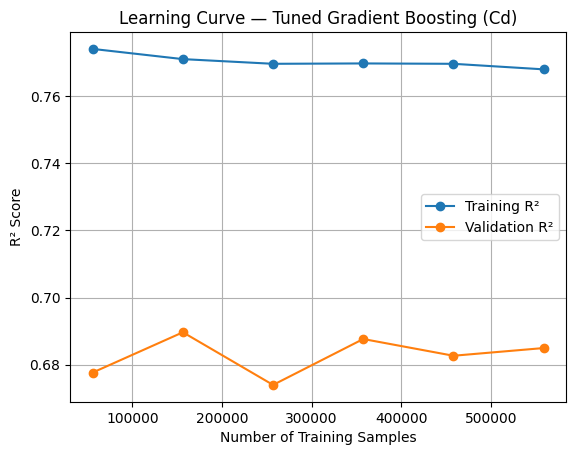

In [26]:
# ------------------------------------------------------------
# CELL 12 (Optional): Learning curve for Tuned GBR on Cd (R²)
# ------------------------------------------------------------
# Matches senior sample "learning curve" idea.
# If slow, reduce points in train_sizes.

train_sizes, train_scores, val_scores = learning_curve(
    estimator=tuned_gbr,
    X=X_scaled,
    y=y_cd,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3,
    scoring="r2",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Training R²")
plt.plot(train_sizes, val_mean, marker="o", label="Validation R²")
plt.xlabel("Number of Training Samples")
plt.ylabel("R² Score")
plt.title("Learning Curve — Tuned Gradient Boosting (Cd)")
plt.legend()
plt.grid(True)
plt.show()


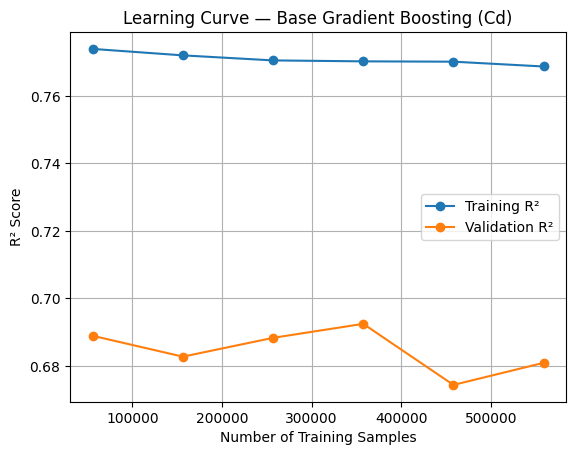

In [27]:
# ------------------------------------------------------------
# Cell 13: Learning Curve — Base Gradient Boosting (Cd, R²)
# ------------------------------------------------------------



train_sizes, train_scores, val_scores = learning_curve(
    estimator=base_gbr,
    X=X_scaled,
    y=y_cd,                      # coefficientDrag
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3,
    scoring="r2",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Training R²")
plt.plot(train_sizes, val_mean, marker="o", label="Validation R²")
plt.xlabel("Number of Training Samples")
plt.ylabel("R² Score")
plt.title("Learning Curve — Base Gradient Boosting (Cd)")
plt.legend()
plt.grid(True)
plt.show()
